## Compute postprocessing metrics for Afragmenter output domains

In [2]:
import pandas as pd
import numpy as np
import os

def load_structure_domain(model_dir):
    """
    Given a model_dir, loads the structure PDB and domain CSV.

    Returns:
        structure: Bio.PDB Structure object
        df_domain (pd.DataFrame): Domain DataFrame
    """
    model_name = os.path.basename(model_dir)
    model_domain_csv = os.path.join(model_dir, f"{model_name}.csv")
    model_pdb = os.path.join(model_dir, f"{model_name}.pdb")

    from Bio.PDB import PDBParser
    parser = PDBParser()

    # Load the PDB file
    structure = parser.get_structure(model_name, model_pdb)
    # Load the domain CSV file
    df_domain = pd.read_csv(model_domain_csv)
    return structure, df_domain

def get_domain_sasa_relative(structure, df_domain):
    """
    Given a structure and df_domain, computes residue-wise relative SASA,
    and adds per-domain sasa_relative_mean and sasa_relative_std columns to the domain dataframe.

    Returns:
        df_domain (pd.DataFrame): domain DataFrame with added metrics.
    """
    import importlib
    get_sasa_relative_module = importlib.import_module("get_sasa_relative")
    importlib.reload(get_sasa_relative_module)
    get_sasa_relative = get_sasa_relative_module.get_sasa_relative

    sasa_relative = get_sasa_relative(structure)

    # Compute mean sasa_relative per domain (convert residue index from 1-based to 0-based)
    df_domain['sasa_relative_mean'] = df_domain.apply(
        lambda row: np.mean(sasa_relative[row['resi_start']-1:row['resi_end']-1]), axis=1)

    # Compute the variability (std) of sasa_relative per domain
    df_domain['sasa_relative_std'] = df_domain.apply(
        lambda row: np.std(sasa_relative[row['resi_start']-1:row['resi_end']-1]), axis=1)
    return df_domain


In [3]:
# List all model directories in domainome
domain_root_dir = "/scratch/ymeng/splitdomain/AFragmenter/data/domainome"
model_dirs = [os.path.join(domain_root_dir, d) for d in os.listdir(domain_root_dir) if os.path.isdir(os.path.join(domain_root_dir, d))]

# Apply postprocessing metrics to each domain
df_domain_all = pd.DataFrame()
for model_dir in model_dirs:
    print(f"Processing {model_dir}")
    structure, df_domain = load_structure_domain(model_dir)
    df_domain = get_domain_sasa_relative(structure, df_domain)
    df_domain_all = pd.concat([df_domain_all, df_domain])

Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-A0A3B3IU53-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-Q13002-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-X6R907-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-P35408-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-C9JL63-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-F5H2D6-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-U3KPW3-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-I3L4Z1-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-O75526-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-Q9NRD5-F1-model_v6
Processing /scratch/ymeng/splitdomain/AFragmenter/data/domainome/AF-A0A8Q3WL48-F1-model_v6
Processing /scratch/ymeng/splitdoma

In [4]:
# write to csv
df_domain_all.to_csv("domain_all_sasa_relative.csv", index=False)

df_domain_all.head()

,structure,domain,n_residues,resi_start,resi_end,mean_pae,sequence,sasa_relative_mean,sasa_relative_std
0,AF-A0A3B3IU53-F1-model_v6.pdb,-1,22,1,22,11.882775,MKMMKTKEEPELQTRREMEERT,0.722455,0.149245
1,AF-A0A3B3IU53-F1-model_v6.pdb,1,48,23,70,3.351020,ITIEIPEVLKKQLEDDCYYINRRKRLVKLPCQTNIITILESYVKHFAI,0.636153,0.162372
0,AF-Q13002-F1-model_v6.pdb,1,33,1,33,11.394130,MKIIFPILSNPVFRRTVKLLLCLLWIGYSQGTT,0.656027,0.135516
1,AF-Q13002-F1-model_v6.pdb,2,385,34,418,6.971705,HVLRFGGIFEYVESGPMGAEELAFRFAVNTINRNRTLLPNTTLTYD...,0.286989,0.270203
2,AF-Q13002-F1-model_v6.pdb,-1,10,419,428,7.931507,GKPANITDSL,0.630909,0.178702


In [35]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.callbacks import Points, InputDeviceState
import ipywidgets as widgets
from IPython.display import display, clear_output

df_domain_positive = df_domain_all[df_domain_all['domain'] > 0]

fig = px.scatter(
    df_domain_positive,
    x='mean_pae',
    y='sasa_relative_mean',
    color='mean_pae',
    color_continuous_scale='viridis',
    hover_data={
        'structure': True,
        'domain': True,
        'sasa_relative_mean': True,
        'sasa_relative_std': True,
        'mean_pae': True
    },
    title="Domain SASA metrics colored by mean PAE",
    width=800,
    height=600,
    opacity=0.7,
)

fig.update_traces(marker=dict(size=10, line=dict(width=0)))

# --- Interactive visualization with click support ---
# Use FigureWidget for interactivity
figw = go.FigureWidget(fig)

out = widgets.Output()
display(figw, out)

def on_point_click(trace, points, selector):
    if not points.point_inds:
        return
    idx = points.point_inds[0]  # the index in the underlying dataframe
    selected_row = df_domain_positive.iloc[idx]
    structure_name = selected_row['structure']
    domain_id = selected_row['domain']
    
    model_dir = os.path.join(domain_root_dir, structure_name.split('.')[0])
    structure, df_domain = load_structure_domain(model_dir)
    
    # Clear previous output (domain visual)
    with out:
        clear_output(wait=True)
        display(widgets.HTML(f"<b>Selected:</b> Structure={structure_name}, Domain={domain_id}"))
        view = view_domain(structure, df_domain, domain=domain_id)
        view.show()

# Attach the callback to all scatter traces
for trace in figw.data:
    trace.on_click(on_point_click)

# Optionally display the "default" one first
with out:
    default_row = df_domain_positive.iloc[0]
    structure_name = default_row['structure']
    domain_id = default_row['domain']
    model_dir = os.path.join(domain_root_dir, structure_name.split('.')[0])
    structure, df_domain = load_structure_domain(model_dir)
    display(widgets.HTML(f"<b>Default selection:</b> Structure={structure_name}, Domain={domain_id}"))
    view = view_domain(structure, df_domain, domain=domain_id)
    view.show()



ImportError: Please install anywidget to use the FigureWidget class

## Visualizations
___________

In [30]:
domain_all = df_domain_all['structure'].unique()

structure_name = 'A0A6Q8PGR8'
# Get all structures matching 'A0A6Q8PGR8'
matching_structures = [s for s in domain_all if structure_name in s]
if matching_structures:
    domtain_structure = matching_structures[0].split('.')[0]
    model_dir = os.path.join(domain_root_dir, domtain_structure)

    structure, df_domain = load_structure_domain(model_dir)
    df_domain = get_domain_sasa_relative(structure, df_domain)

    import importlib
    get_sasa_relative_module = importlib.import_module("get_sasa_relative")
    importlib.reload(get_sasa_relative_module)
    get_sasa_relative = get_sasa_relative_module.get_sasa_relative

    sasa_relative = get_sasa_relative(structure)
else:
    raise ValueError(f"No structure found containing '{structure_name}' in its name.")

df_domain

,structure,domain,n_residues,resi_start,resi_end,mean_pae,sequence,sasa_relative_mean,sasa_relative_std
0,AF-A0A6Q8PGR8-F1-model_v6.pdb,-1,111,1,111,23.105358,MAAGGSGCTSSAGGGGRGVNPRRTGRSRFPLCGGRRDHKGLTHIFN...,0.792040,0.216292
1,AF-A0A6Q8PGR8-F1-model_v6.pdb,1,38,112,149,10.778662,AGQEALLKQEQAKIIRFERQAEEFLNAVFYRKDSPWVS,0.604683,0.129826
2,AF-A0A6Q8PGR8-F1-model_v6.pdb,-2,267,150,416,26.768372,DPNIPLVAREIMQRMIQQFAAEYTSKNSSTQDPSQPNSTKNQSLPK...,0.924530,0.141167
3,AF-A0A6Q8PGR8-F1-model_v6.pdb,2,31,417,447,14.331296,QVRGMDLSWESRTGDQYSYSSLVMGSQTESA,0.962130,0.062616
4,AF-A0A6Q8PGR8-F1-model_v6.pdb,-3,60,448,507,20.477397,LSKKLRAILPKQSRKSMLDAGPDSWGSDAEQSTSGQPYPTSDQEGD...,0.962339,0.072687
5,AF-A0A6Q8PGR8-F1-model_v6.pdb,3,46,508,553,3.637597,QYNSEILEEAISVVMSGKMSVSKAQSIYGIPHSTLEYKVKERLGTL,0.398217,0.226978
6,AF-A0A6Q8PGR8-F1-model_v6.pdb,-4,40,554,593,17.592488,KNPPKKKMKLMRSEGPDVSVKIELDPQGEAAQSANESKNE,0.926579,0.079532


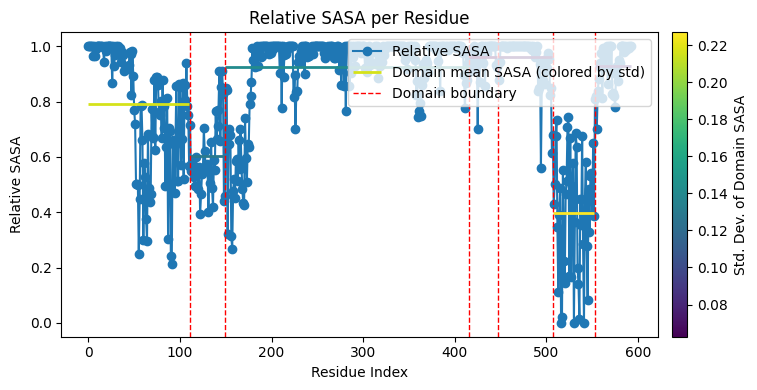

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt

all_starts = df_domain['resi_start'].tolist()
all_ends = df_domain['resi_end'].tolist()
mean_sasa_values = df_domain['sasa_relative_mean'].tolist()
std_sasa_values = df_domain['sasa_relative_std'].tolist()

# Set up the figure and axis explicitly for colorbar compatibility
fig, ax = plt.subplots(figsize=(8, 4))

# Plot sasa_relative (y-axis) ~ residue index (x-axis)
ax.plot(range(len(sasa_relative)), sasa_relative, marker='o', linestyle='-', label="Relative SASA")

# Prepare colormap for std_sasa_values
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(std_sasa_values), vmax=max(std_sasa_values))

# Plot mean_sasa_values as colored lines, color by std_sasa_values
for i, (start, end, mean_val, std_val) in enumerate(zip(all_starts, all_ends, mean_sasa_values, std_sasa_values)):
    color = cmap(norm(std_val))
    ax.hlines(mean_val, start-1, end-1, color=color, linewidth=2,
              label='Domain mean SASA (colored by std)' if i == 0 else "")

ax.set_xlabel("Residue Index")
ax.set_ylabel("Relative SASA")
ax.set_title("Relative SASA per Residue")

# --- Add domain boundaries as red dashed vertical lines ---
resi_boundaries = []
for i in range(1, len(all_starts)):
    resi_boundaries.append(all_starts[i]-1)
for end in all_ends[:-1]:
    resi_boundaries.append(end)
resi_boundaries = sorted(set([b for b in resi_boundaries if b > 0]))

for i, boundary in enumerate(resi_boundaries):
    ax.axvline(boundary, color='red', linestyle='--', linewidth=1,
               label='Domain boundary' if i == 0 else "")

# Add colorbar for std_sasa_values; use ax argument to avoid ValueError
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Std. Dev. of Domain SASA')

# Only add legend entry once per handle
handles, labels = ax.get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right")

fig.tight_layout()
plt.show()


In [29]:
def show_domains_vs_sasa_view(
    structure,
    df_domain,
    sasa_relative,
    width=400,
    height=400,
):
    """
    Visualize side-by-side:
    - Left: Structure colored by domain (unique color per domain, from df_domain['resi_start','resi_end'])
    - Middle: Structure colored by normalized sasa_relative per residue (white=buried to blue=exposed)
    - Right: Structure colored by per-domain sasa_relative_mean from df_domain (white=buried to red=exposed)
    
    Args:
        structure: Bio.PDB Structure object
        df_domain: DataFrame with 'resi_start', 'resi_end', and 'sasa_relative_mean' columns
        sasa_relative: List or np.array of per-residue relative SASA values, in the same order as the residues in structure
        width, height: Size of each view
    Returns:
        py3Dmol view with 1x3 grid
    """
    import py3Dmol
    import numpy as np
    from Bio.PDB import PDBIO
    from io import StringIO

    # --- write PDB structure to string ---
    pdbio = PDBIO()
    pdbio.set_structure(structure)
    pdb_buf = StringIO()
    pdbio.save(pdb_buf)
    pdb_string = pdb_buf.getvalue()
    
    # Palette for domains (repeat if more domains)
    palette = [
        'red', 'orange', 'yellow', 'green', 'cyan',
        'blue', 'magenta', 'purple', 'salmon', 'lime'
    ]
    
    # Normalize sasa_relative between 0 and 1 for color map
    norm_sasa = np.clip(np.array(sasa_relative), 0, 1)

    # List of (chain_id, resseq) in same order as sasa_relative
    res_ids = []
    for model in structure:
        for chain in model:
            for res in chain:
                res_ids.append((chain.get_id(), res.get_id()[1]))  # (chain, resseq)
    
    # Sanity: If residue count mismatches, abort
    assert len(res_ids) == len(sasa_relative), f"Residue/SASA length mismatch: {len(res_ids)}, {len(sasa_relative)}"
    
    # --- py3Dmol view setup: 1x3 grid ---
    view = py3Dmol.view(viewergrid=(1,3), width=width*3, height=height)
    
    # Add structure to all panels
    view.addModel(pdb_string, 'pdb', viewer=(0,0))
    view.addModel(pdb_string, 'pdb', viewer=(0,1))
    view.addModel(pdb_string, 'pdb', viewer=(0,2))
    for v in [(0,0), (0,1), (0,2)]:
        view.setBackgroundColor('white', viewer=v)
    
    # ---- LEFT: color by domain ----
    # all cartoon lightgrey first
    view.setStyle({'cartoon': {'color': 'lightgrey'}}, viewer=(0,0))
    
    for i, row in df_domain.iterrows():
        color = palette[i % len(palette)]
        # PDB residue selection is 1-based (matching resseq), all chains
        sel = {'resi': f"{row['resi_start']}-{row['resi_end']}"}
        view.setStyle(sel, {'cartoon': {'color': color}}, viewer=(0,0))
    view.zoomTo(viewer=(0,0))

    # ---- MIDDLE: color by sasa_relative using white-to-blue ----
    view.setStyle({'cartoon': {}}, viewer=(0,1))
    
    def white_to_blue(norm_val):
        r = (1 - norm_val) * 1 + norm_val * 0
        g = (1 - norm_val) * 1 + norm_val * 0
        b = (1 - norm_val) * 1 + norm_val * 1
        return (r,g,b)
    
    for idx, (chain_id, resseq) in enumerate(res_ids):
        val = norm_sasa[idx]
        color_rgb = white_to_blue(val)
        hex_color = '#%02x%02x%02x' % tuple(int(255*x) for x in color_rgb)
        sel = {'chain': chain_id, 'resi': str(resseq)}
        view.setStyle(sel, {'cartoon': {'color': hex_color}}, viewer=(0,1))
    view.zoomTo(viewer=(0,1))

    # ---- RIGHT: color by per-domain sasa_relative_mean using white-to-red ----
    view.setStyle({'cartoon': {'color': 'lightgrey'}}, viewer=(0,2))

    def white_to_red(norm_val):
        # norm_val 0: white (#ffffff); norm_val 1: red (#ff0000)
        r = 1
        g = 1 - norm_val
        b = 1 - norm_val
        return (r, g, b)

    # Make a mapping of each residue to its domain sasa_relative_mean
    # For each row/domain, set all residues in that domain to that mean value
    resseq_sasa_mean = dict()  # (start_resi, end_resi): mean
    for i, row in df_domain.iterrows():
        start = int(row['resi_start'])
        end = int(row['resi_end'])
        mean_val = float(row['sasa_relative_mean'])
        for resi in range(start, end+1):
            resseq_sasa_mean[resi] = mean_val

    for idx, (chain_id, resseq) in enumerate(res_ids):
        mean_val = resseq_sasa_mean.get(resseq, 0.0)
        mean_val = np.clip(mean_val, 0, 1)
        color_rgb = white_to_red(mean_val)
        hex_color = '#%02x%02x%02x' % tuple(int(255*x) for x in color_rgb)
        sel = {'chain': chain_id, 'resi': str(resseq)}
        view.setStyle(sel, {'cartoon': {'color': hex_color}}, viewer=(0,2))
    view.zoomTo(viewer=(0,2))
    
    # --- Titles (labels) on each ---
    view.addLabel(
        'DOMAIN color',
        {
            "fontColor": "black",
            "backgroundColor": "rgba(0,0,0,0)",
            "borderColor": "rgba(0,0,0,0)",
            "inFront": True,
            "showBackground": False,
            "fontSize": 12,
            "alignment": "topLeft"
        },
        viewer=(0,0)
    )
    view.addLabel(
        'Relative SASA',
        {
            "fontColor": "black",
            "backgroundColor": "rgba(0,0,0,0)",
            "borderColor": "rgba(0,0,0,0)",
            "inFront": True,
            "showBackground": False,
            "fontSize": 12,
            "alignment": "topLeft"
        },
        viewer=(0,1)
    )
    view.addLabel(
        'Domain mean SASA',
        {
            "fontColor": "black",
            "backgroundColor": "rgba(0,0,0,0)",
            "borderColor": "rgba(0,0,0,0)",
            "inFront": True,
            "showBackground": False,
            "fontSize": 12,
            "alignment": "topLeft"
        },
        viewer=(0,2)
    )
    return view

# Usage example in notebook:
view = show_domains_vs_sasa_view(structure, df_domain, sasa_relative)
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [32]:
def view_domain(structure, df_domain, domain, width=400, height=400):
    """
    Show structure in grey, and highlight the selected domain in blue.
    
    Args:
        structure: Bio.PDB Structure object
        df_domain: DataFrame with columns 'domain', 'resi_start', and 'resi_end'
        domain: domain ID to highlight (should match df_domain['domain'])
        width, height: Size of view
    Returns:
        py3Dmol view
    """
    import py3Dmol
    from Bio.PDB import PDBIO
    from io import StringIO

    # Write PDB structure to string for py3Dmol
    pdbio = PDBIO()
    pdbio.set_structure(structure)
    pdb_buf = StringIO()
    pdbio.save(pdb_buf)
    pdb_string = pdb_buf.getvalue()

    # Find row for the selected domain
    domain_row = df_domain[df_domain['domain'] == domain]
    if len(domain_row) == 0:
        raise ValueError(f"Domain '{domain}' not found in df_domain.")
    domain_row = domain_row.iloc[0]
    resi_start = int(domain_row['resi_start'])
    resi_end = int(domain_row['resi_end'])

    view = py3Dmol.view(width=width, height=height)
    view.addModel(pdb_string, 'pdb')
    view.setBackgroundColor('white')
    # Show all cartoon in light grey
    view.setStyle({'cartoon': {'color': 'lightgrey'}})
    # Highlight the selected domain in blue (all chains)
    sel = {'resi': f"{resi_start}-{resi_end}"}
    view.setStyle(sel, {'cartoon': {'color': 'blue'}})
    view.zoomTo()
    return view

# Usage example in notebook:
view = view_domain(structure, df_domain, domain=1)
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.